
**Mini Project**

*Cats vs Dogs Image Classifier using Transfer Learning*

Use the **Cats vs Dogs** dataset provided by **TensorFlow Datasets (TFDS)**.

* Loads and preprocesses the dataset.

In [ ]:
import tensorflow_datasets as tfds
!pip install --upgrade tensorflow_datasets
!pip install --upgrade protobuf



In [6]:
train, val = tfds.load(
    "cats_vs_dogs",
    split=["train[:80%]", "train[80%:]"],
    with_info = False,
    as_supervised=True,
)


In [18]:


(train, val), ds_info = tfds.load(
    "cats_vs_dogs",
    split=["train[:80%]", "train[80%:]"],
    with_info=True,
    as_supervised=True,
)

print(f"Classes: {ds_info.features['label'].names}")
print(f"Train examples: {tf.data.experimental.cardinality(train).numpy()}")
print(f"Val examples:   {tf.data.experimental.cardinality(val).numpy()}")


def preprocess(image, label):

    image = tf.image.resize(image, (160, 160))
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label


train_ds = (
    train
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)


for images, labels in train_ds.take(1):
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)


Classes: ['cat', 'dog']
Train examples: 18610
Val examples:   4652
Batch image shape: (32, 160, 160, 3)
Batch label shape: (32,)


Build an image classification model that:

* Uses **MobileNetV2** as the pre-trained backbone.
* Freezes the base model.
* Adds custom classification layers.
* Trains the model.
* Evaluates it on the validation dataset.
* Displays sample predictions.
* Plots the training and validation accuracy and loss curves.


In [19]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
import tensorflow as tf

base_model = MobileNetV2(
    input_shape = (160,160,3) ,
    include_top = False,
    weights = 'imagenet'
)

base_model.trainable = False

model= Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation = 'sigmoid') # Changed to 1 unit for binary classification with sigmoid
])

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-5),
    loss = tf.keras.losses.BinaryCrossentropy(),
    metrics = ['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
history =  model.fit(train_ds,validation_data = val_ds , epochs =10)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 79s 104ms/step - accuracy: 0.4646 - loss: 0.8210 - val_accuracy: 0.6197 - val_loss: 0.6595
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 35s 58ms/step - accuracy: 0.7259 - loss: 0.5572 - val_accuracy: 0.8205 - val_loss: 0.4635
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 33s 55ms/step - accuracy: 0.8558 - loss: 0.4026 - val_accuracy: 0.8919 - val_loss: 0.3449
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 36s 59ms/step - accuracy: 0.9105 - loss: 0.3074 - val_accuracy: 0.9265 - val_loss: 0.2698
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 39s 64ms/step - accuracy: 0.9337 - loss: 0.2457 - val_accuracy: 0.9460 - val_loss: 0.2198
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.9467 - loss: 0.2037 - val_accuracy: 0.9559 - val_loss: 0.1850
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 38s 63ms/step - accuracy: 0.9552 - loss: 0.1739 - val_accuracy: 0.9617 - val_loss: 0.1596
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 33s 55ms/step - accuracy: 0.9599 - loss: 0.1519 -

In [22]:

val_loss, val_accuracy = model.evaluate(val_ds)
print(f"Validation loss:     {val_loss}")
print(f"Validation accuracy: {val_accuracy}")


146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.9688 - loss: 0.1145
Validation loss:     0.11447031795978546
Validation accuracy: 0.9688305854797363


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


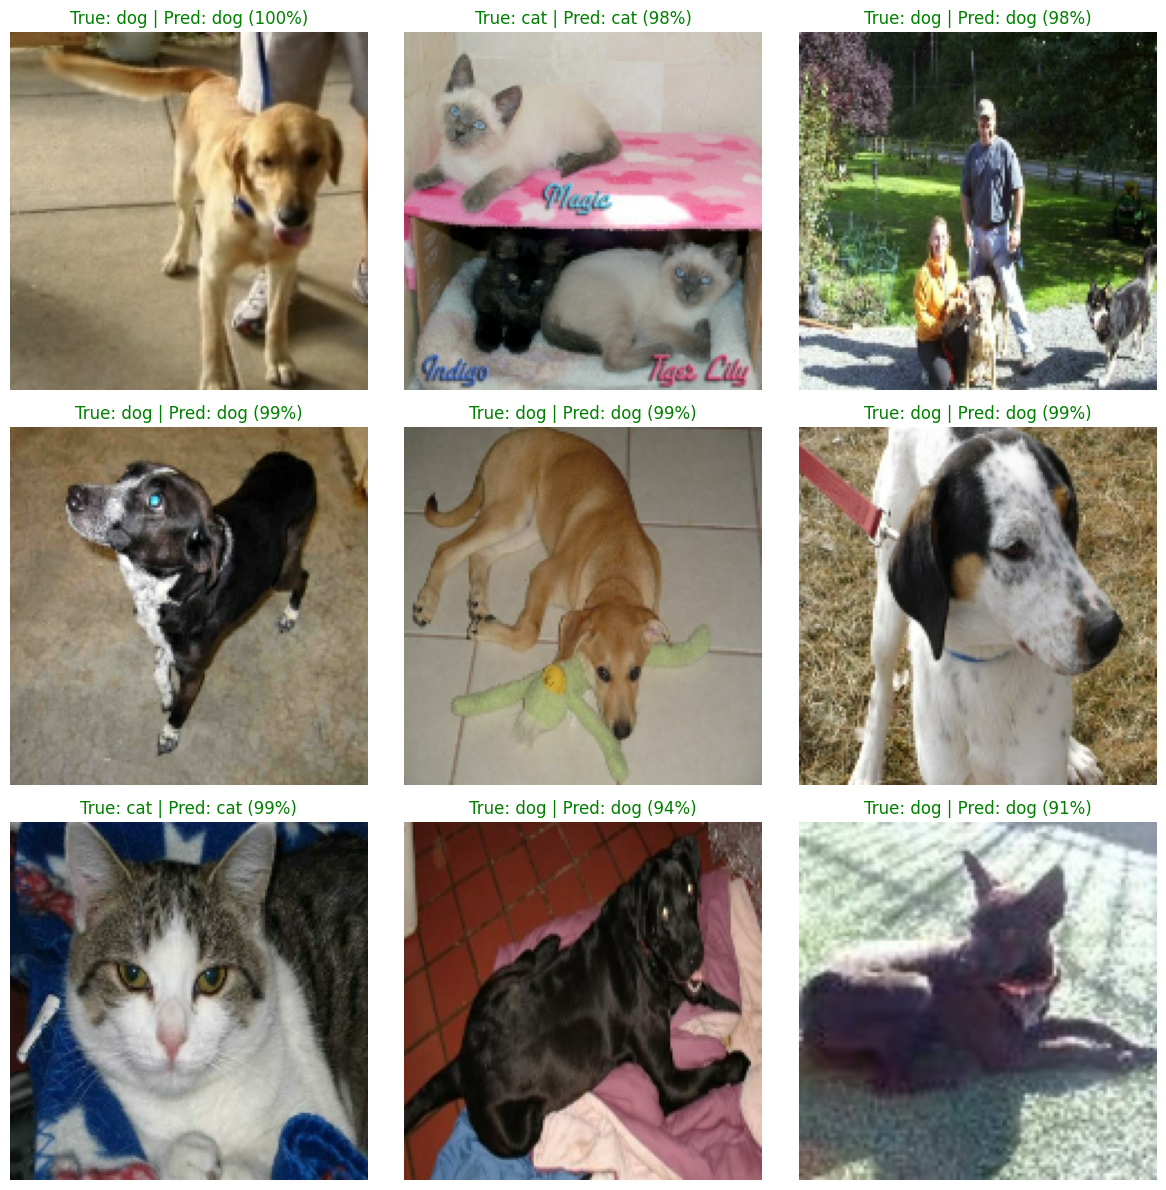

In [23]:

import matplotlib.pyplot as plt

class_names = ds_info.features["label"].names

images, labels = next(iter(val_ds))
predictions = model.predict(images)
predicted_labels = (predictions.squeeze() > 0.5).astype(int)

plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i + 1)

    display_img = (images[i].numpy() + 1) / 2.0
    plt.imshow(display_img)

    true_label = class_names[labels[i].numpy()]
    pred_label = class_names[predicted_labels[i]]
    confidence = predictions[i][0] if pred_label == "dog" else 1 - predictions[i][0]

    color = "green" if true_label == pred_label else "red"
    plt.title(f"True: {true_label} | Pred: {pred_label} ({confidence:.0%})", color=color)
    plt.axis("off")

plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=150)
plt.show()


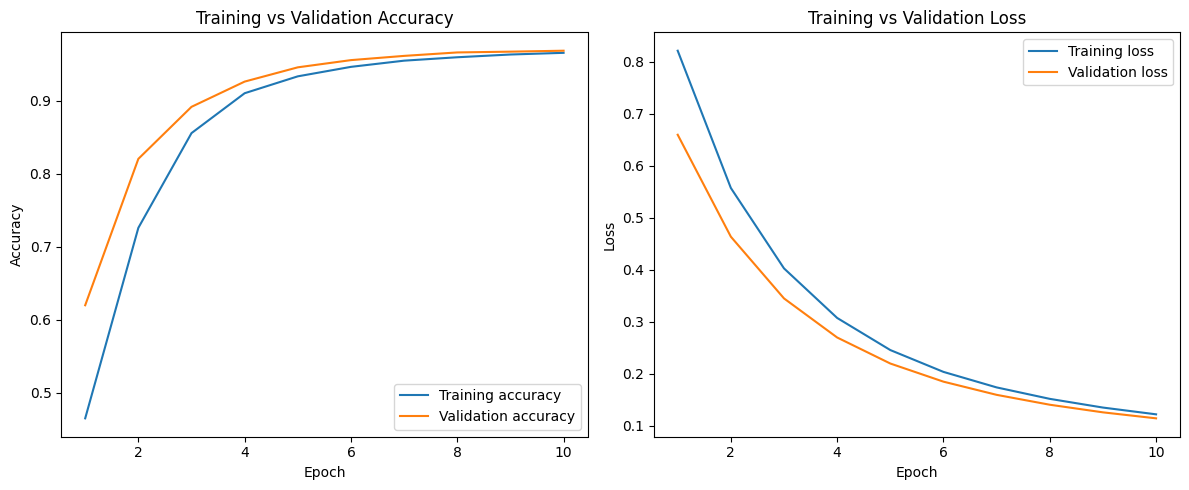

In [24]:

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss_hist = history.history["val_loss"]
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training accuracy")
plt.plot(epochs_range, val_acc, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training loss")
plt.plot(epochs_range, val_loss_hist, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()